<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter6/6_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 주성분 분석
비지도 학습의 대표적인 학습인 주성분 분석에 대해 공부할 것.


## 차원축소
저장공간을 절약.

과일 사진은 10000개의 픽셀이 있기 때문에 10000개의 특성이 있는거고 이것이 10000차원 벡터를 가지고 있어 이것을 줄이면 절약이 됨.

특성이 많으면 선형 모델의 성능이 높아지고 훈련 데이터가 과대적합이 되었었는데 차원 축소는 데이터를 가장 잘 나타내는 일부 특성을 선택해 데이터 크기를 줄이고 지도 학습 모델의 성능을 향상 시킬수 있음.


## 주성분 분석(PCA)

In [ ]:
#데이터 다운로드
!wget https://bit.ly/fruits_300_data -O fruits_300.npy

--2026-03-29 03:23:54--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-03-29 03:23:54--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-03-29 03:23:55--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [ ]:
#데이터 로드 및 차원 변환
import numpy as np
fruits = np.load('fruits_300.npy')

fruits_2d = fruits.reshape(-1, 100*100)

In [ ]:
#주성분 분석(10000개의 특성을 50개 줄임)
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
pca.fit(fruits_2d)

PCA(n_components=50)

In [ ]:
#PCA 클래스가 찾은 주성분 확인(50개의 주성분과 원본 데이터의 특성 개수)
print(pca.components_.shape)

(50, 10000)


In [ ]:
#앞 절에서 사용했던 유틸리티 함수 사용
import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1):
    n = len(arr)    # n은 샘플 개수입니다
    # 한 줄에 10개씩 이미지를 그립니다. 샘플 개수를 10으로 나누어 전체 행 개수를 계산합니다.
    rows = int(np.ceil(n/10))
    # 행이 1개 이면 열 개수는 샘플 개수입니다. 그렇지 않으면 10개입니다.
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols*ratio, rows*ratio), squeeze=False)
    for i in range(rows):
        for j in range(cols):
            if i*10 + j < n:    # n 개까지만 그립니다.
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off')
    plt.show()

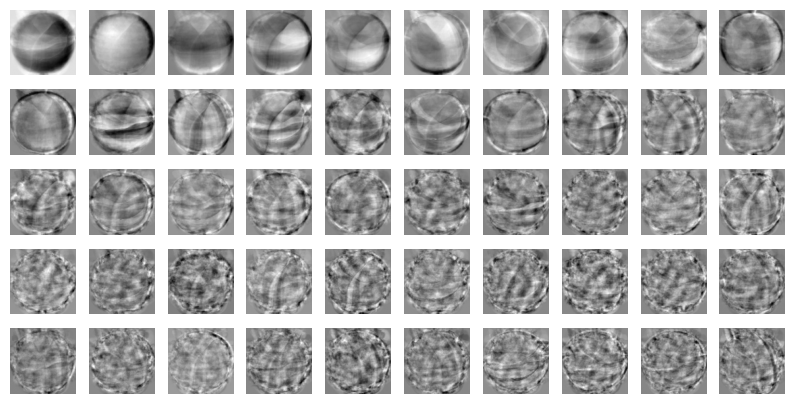

In [ ]:
#주성분 이미지 출력(원본 데이터에서 가장 분산이 큰 방향을 순서대로 나타낸 것.)
draw_fruits(pca.components_.reshape(-1, 100, 100))

In [ ]:
#찾은 주성분을 사용해 원본 데이터를 주성분에 투용하여 특성의 개수를 10000개에서 50개로 줄일 수 있다.
print(fruits_2d.shape)

(300, 10000)


In [ ]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 50)


## 재구성 하기(inverse)
차원을 축소한 것이기에 어느 정도 손실이 발생하는데 최대한 분산이 큰 방향으로 데이터를 투영하였기에 원본 데이터를 상당 부분 재구성 할수 있다.


In [ ]:
#복원하기
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

(300, 10000)


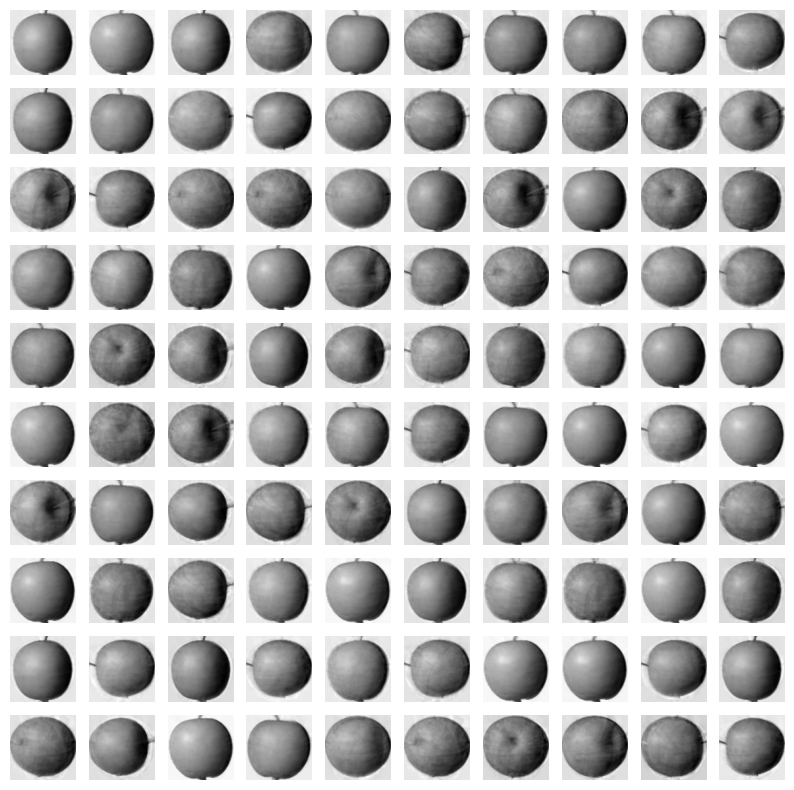

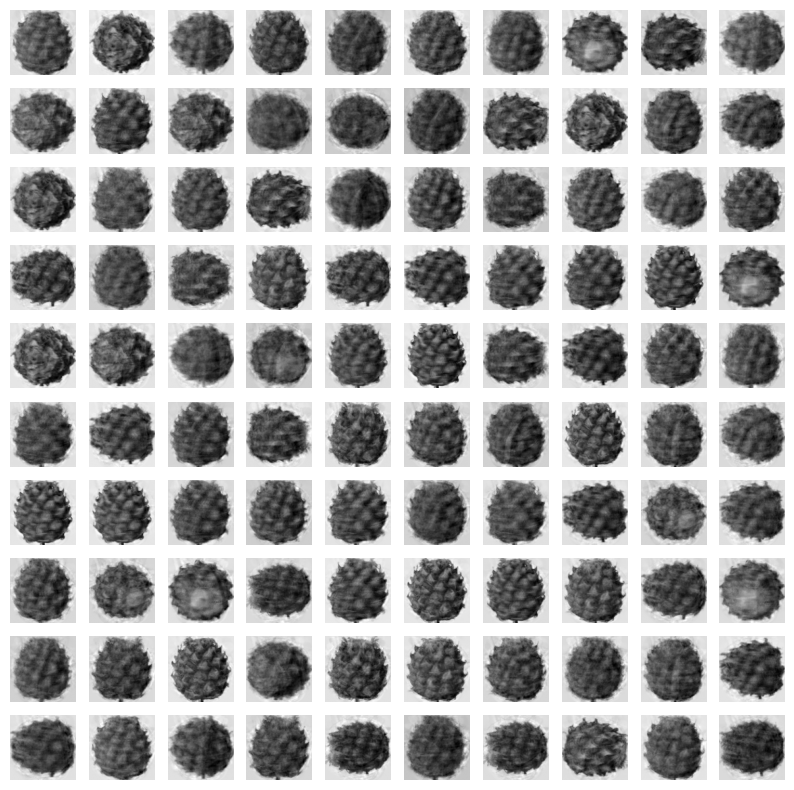

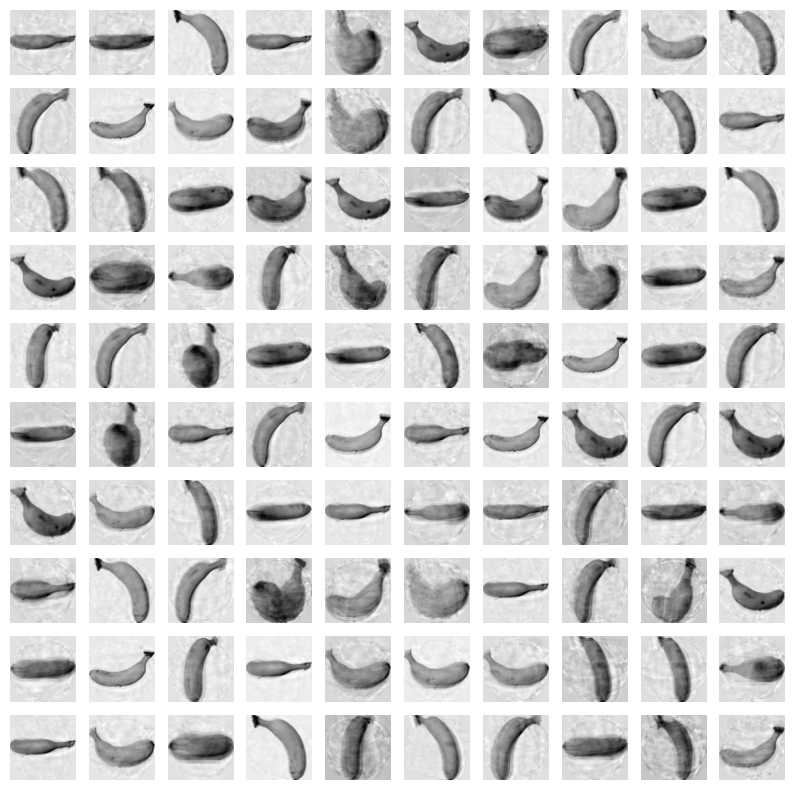

In [ ]:
#이미지 출력해보기
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)

for start in [0, 100, 200]:
  draw_fruits(fruits_reconstruct[start:start+100])
  print('\n')

## 설명된 분산
주성분이 원본 데이터의 분산을 얼마나 잘 나타내는지 기록한 값

In [ ]:
#총 분산 비율
print(np.sum(pca.explained_variance_ratio_))

0.9215343816963737


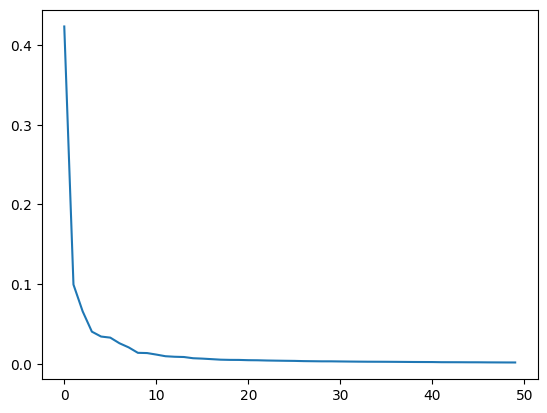

In [ ]:
#92%가 넘는 분산 유지. 덕분에 원본 데이터 복원하였을때 품질이 높았음.
#분산 비율 그려보면 10개 이전에는 분산이 컸다가 줄어드는 것을 볼 수 있음
plt.plot(pca.explained_variance_ratio_)
plt.show()

##다른 알고리즘과 함께 사용하기
분류기와 함께 사용하기

### 로지스틱 회귀

In [ ]:
#로지스틱 회귀는 4-1에서 했었음
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

#사과 0, 파인애플 1, 바나나 2 타깃 만들기
target = np.array([0]*100 + [1]*100 + [2]*100)

In [ ]:
#먼저 원본데이터 사용하여 교차검증
from sklearn.model_selection import cross_validate

#교차검증 점수는 높고 훈련시간은 0.75초
scores = cross_validate(lr, fruits_2d, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
1.2177165508270265


In [ ]:
#축소 데이터로 비교
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.01630887985229492


50개의 축소된 데이터로 해도 정확도가 높고 속도는 매우 빨라졌다

In [ ]:
#앞서 주성분의 개수를 지정하기 대신 비율로 가능
pca = PCA(n_components=0.5)
pca.fit(fruits_2d)

PCA(n_components=0.5)

In [ ]:
#설명된 분산의 50%에 달하는 주성분을 찾도록 해서 2가 나옴. 2개의 특성만으로 원본 데이터에 있는 분산의 50%까지 표현할 수 있음
print(pca.n_components_)

2


In [ ]:
#이 모델 성능 확인
#원본 데이터 변환
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 2)


In [ ]:
#교차 검증
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.99
0.029026365280151366


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

## 군집과 함께 사용하기

In [ ]:
#차원 축소 된 데이터를 사용해 클러스터 찾아보기
from sklearn.cluster import KMeans
km = KMeans(n_clusters = 3, random_state=42)

#훈련 및 클러스터 개수
km.fit(fruits_pca)
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))


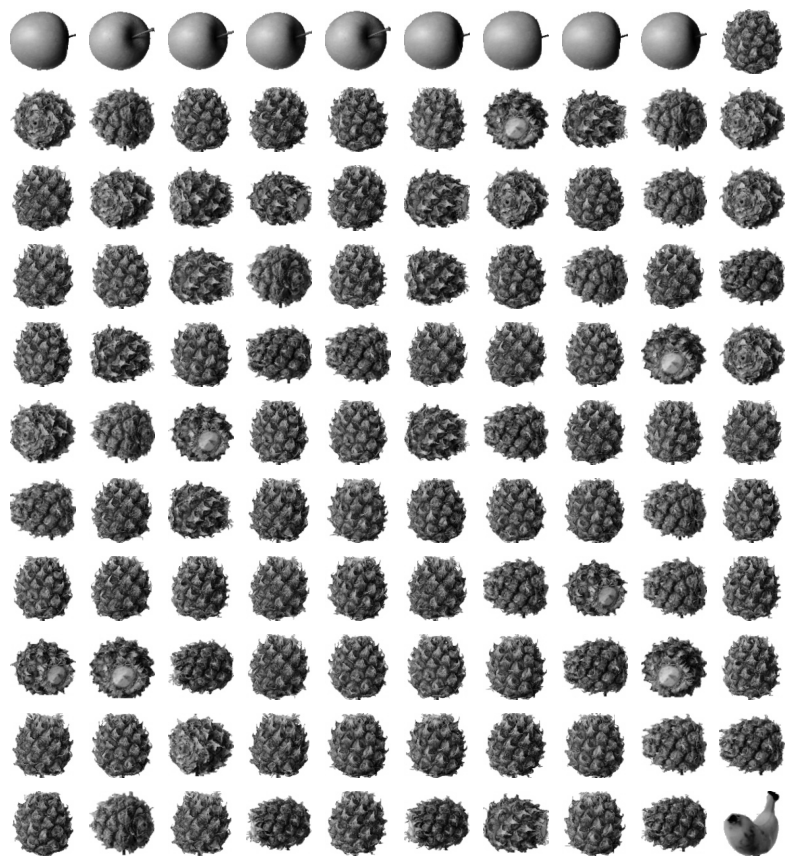

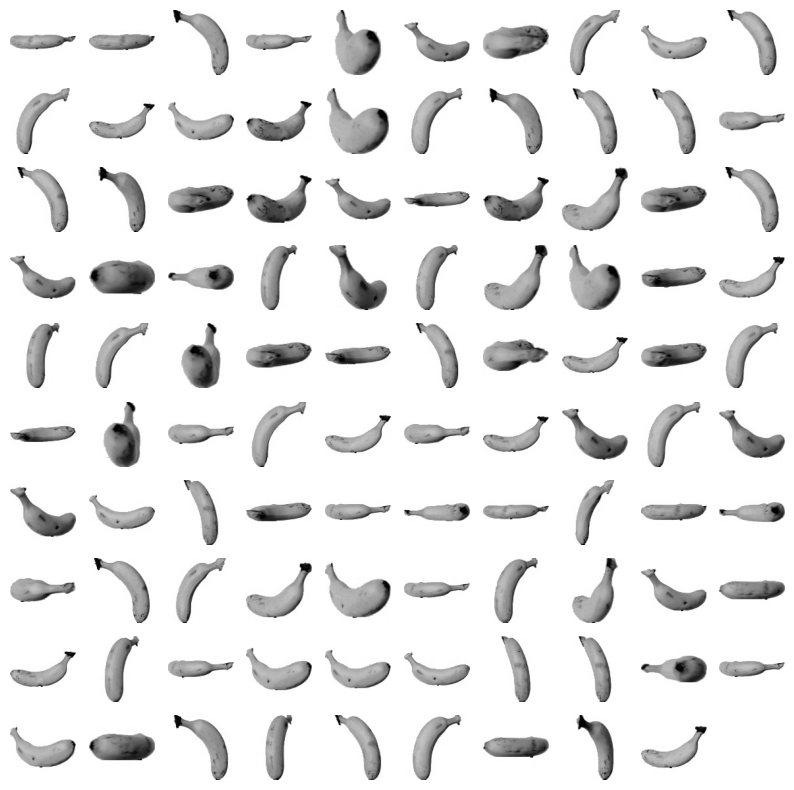

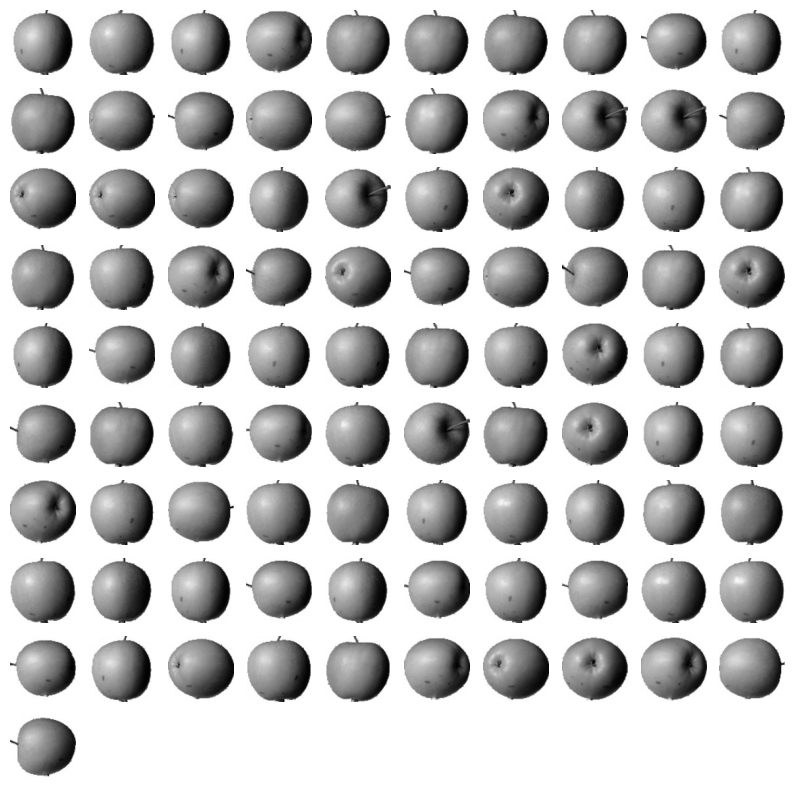

In [ ]:
#이미지 출력
for label in range(0, 3):
    draw_fruits(fruits[km.labels_ == label])
    print("\n")

## 시각화
군집 레이블을 가지고 시각화 가능

훈련 데이터의 차원을 줄이면 얻을 수 있는 장점

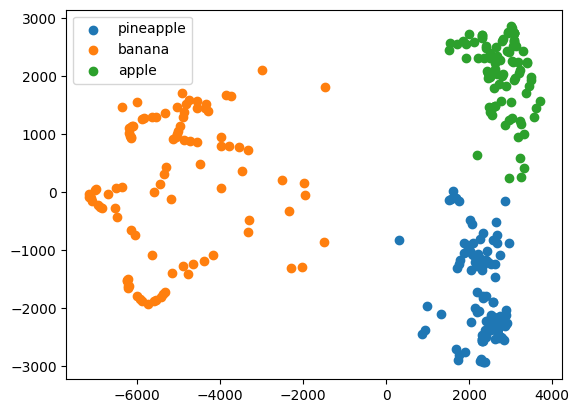

In [ ]:
for label in range(0, 3):
  data = fruits_pca[km.labels_ == label]
  plt.scatter(data[:,0], data[:,1])
plt.legend(['pineapple', 'banana', 'apple'])
plt.show()

이 장에서는 대표적인 비지도 학습 문제 중 하나인 차원 축소에 대해 알아봄.

차원 축소 장점: 데이터셋의 크기 감소, 비교적 시각화 쉬움, 축소된 데이터를 지도 학습 알고리즘이나 다른 비지도 학습 알고리즘에 재사용하여 성능 강화 및 훈련속도 개선 등

축소된 데이터를 가지고 원본 데이터를 어느정도 복구 가능